# Analysis 3: Race and Person Seach

This analysis examines whether race is associated with whether a stopped person was searched in the 2017 Minneapolis Police Stop dataset.

The two variables used are:

- `race`
- `personSearch`

The main statistical method is a chi-square test of independence.

### IMPORT DATA

In [1]:
import pandas as pd
df = pd.read_csv("MplsStops.csv")
df.head()

,Unnamed: 0,idNum,date,problem,MDC,citationIssued,personSearch,vehicleSearch,preRace,race,gender,lat,long,policePrecinct,neighborhood
0,6823,17-000003,2017-01-01 00:00:42,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Unknown,44.966617,-93.246458,1,Cedar Riverside
1,6824,17-000007,2017-01-01 00:03:07,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Male,44.980450,-93.271340,1,Downtown West
2,6825,17-000073,2017-01-01 00:23:15,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.948350,-93.275380,5,Whittier
3,6826,17-000092,2017-01-01 00:33:48,suspicious,MDC,NaN,NO,NO,Unknown,East African,Male,44.948360,-93.281350,5,Whittier
4,6827,17-000098,2017-01-01 00:37:58,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.979078,-93.262076,1,Downtown West


In [2]:
# Standardize column names
df.columns = df.columns.str.strip()

# Clean the two columns needed for this analysis
df["race"] = df["race"].astype("string").str.strip().str.lower()
df["personSearch"] = df["personSearch"].astype("string").str.strip().str.lower()

# Keep only rows with usable race and personSearch values
df_analysis = df.dropna(subset=["race", "personSearch"]).copy()

# Remove unknown race because it is not a specific racial group
df_analysis = df_analysis[df_analysis["race"] != "unknown"]

# Keep only yes/no personSearch values
df_analysis = df_analysis[df_analysis["personSearch"].isin(["yes", "no"])]

df_analysis[["race", "personSearch"]].head()

,race,personSearch
2,white,no
3,east african,no
4,white,no
5,east african,no
6,black,no


In [3]:
print(df_analysis["race"].value_counts())
print()
print(df_analysis["personSearch"].value_counts())

race
black              15220
white              11703
east african        2188
latino              1858
native american     1516
other               1348
asian                647
Name: count, dtype: Int64

personSearch
no     29342
yes     5138
Name: count, dtype: Int64


In [4]:
race_search_table = pd.crosstab(
    df_analysis["race"],
    df_analysis["personSearch"]
)

race_search_table

personSearch,no,yes
race,,
asian,585,62
black,12121,3099
east african,2020,168
latino,1637,221
native american,1052,464
other,1178,170
white,10749,954


In [5]:
race_search_percent = pd.crosstab(
    df_analysis["race"],
    df_analysis["personSearch"],
    normalize="index"
) * 100

race_search_percent.round(2)

personSearch,no,yes
race,,
asian,90.42,9.58
black,79.64,20.36
east african,92.32,7.68
latino,88.11,11.89
native american,69.39,30.61
other,87.39,12.61
white,91.85,8.15


In [6]:
search_rate_by_race = (
    df_analysis
    .assign(person_searched=df_analysis["personSearch"] == "yes")
    .groupby("race")["person_searched"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

search_rate_by_race

race
native american     30.60686
black              20.361367
other              12.611276
latino              11.89451
asian               9.582689
white               8.151756
east african        7.678245
Name: person_searched, dtype: Float64

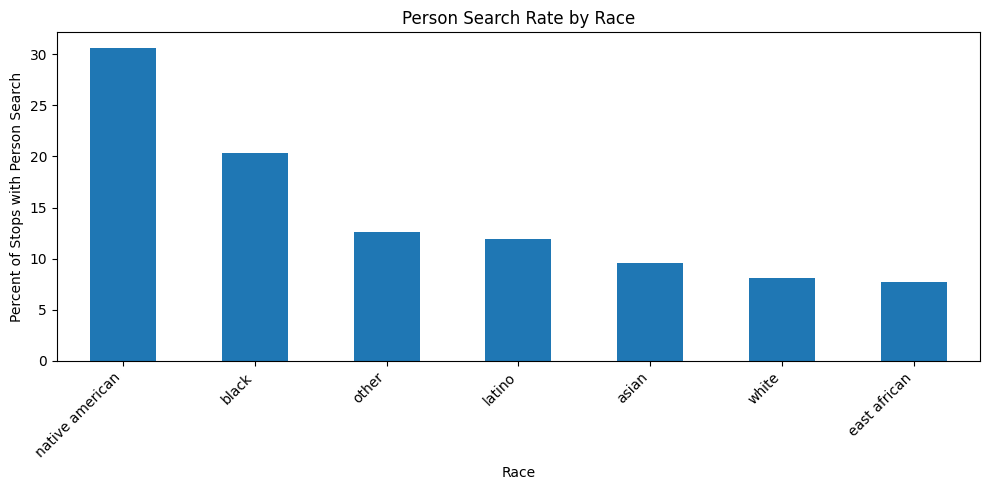

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

search_rate_by_race.plot(kind="bar")

plt.title("Person Search Rate by Race")
plt.xlabel("Race")
plt.ylabel("Percent of Stops with Person Search")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Chi-Square Test of Independence

The chi-square test checks whether race and person search outcome are independent.

Hypotheses:

- \(H_0\): Race and person search are independent.
- \(H_a\): Race and person search are associated.

In [10]:
from statsmodels.stats.contingency_tables import Table

race_search_table = pd.crosstab(
    df_analysis["race"],
    df_analysis["personSearch"]
)

race_search_table

personSearch,no,yes
race,,
asian,585,62
black,12121,3099
east african,2020,168
latino,1637,221
native american,1052,464
other,1178,170
white,10749,954


In [11]:
sm_table = Table(race_search_table)

result = sm_table.test_nominal_association()

print("Chi-square statistic:", result.statistic)
print("Degrees of freedom:", result.df)
print("p-value:", result.pvalue)

Chi-square statistic: 1196.4122097352576
Degrees of freedom: 6
p-value: 0.0


In [12]:
expected_counts = pd.DataFrame(
    sm_table.fittedvalues,
    index=race_search_table.index,
    columns=race_search_table.columns
)

display(expected_counts.round(2))

print("Smallest expected count:", expected_counts.min().min())



personSearch,no,yes
race,,
asian,550.59,96.41
black,12952.01,2267.99
east african,1861.96,326.04
latino,1581.13,276.87
native american,1290.09,225.91
other,1147.13,200.87
white,9959.09,1743.91


Smallest expected count: 96.41200696055685


### Chi-Square Test Conclusion

The hypotheses for this test were:

- \(H_0\): Race and person search outcome are independent.
- \(H_a\): Race and person search outcome are associated.

The chi-square test produced a test statistic of 1196.4122 with 6 degrees of freedom and a p-value that was less 0.001.

Using a significance level of 0.05, we reject the null hypothesis.

In context, this means there is **strong evidence** that race and whether a person was searched **ARE** associated in the 2017 Minneapolis police stop data.

This result shows association, not causation. Other variables, such as stop type, precinct, neighborhood, and reason for the stop, may also affect whether a person was searched.

FOR APPENDIX:

## Chi-Square Test of Independence: Race and Person Search

The purpose of this test was to determine whether race and person-search outcome were independent.

Hypotheses:

\(H_0\): Race and person-search outcome are independent.

\(H_a\): Race and person-search outcome are associated.

A chi-square test of independence was conducted using race and personSearch.

Test results:

- Chi-square statistic: 1196.41
- Degrees of freedom: 6
- p-value: < 0.001
- Smallest expected count: 96.41

Because the p-value is less than 0.05, we **reject** the null hypothesis. There is strong evidence that race and person-search outcome are associated in the 2017 Minneapolis police stop data.

The expected counts condition was satisfied because all expected counts were greater than 5.

### **FOR EXECUTIVE PAPER**

The chi-square test tells you there is an association, but it does not tell the CEO which races had higher/lower search rates.

So now you need the conditional percent table:

(The table below shows the percentage of stops within each race category that did or did not result in a person search. Percentages are calculated within each race group, so each row adds to 100%).

In [15]:
#SAME AS CELL 5
race_search_percent = pd.crosstab(
    df_analysis["race"],
    df_analysis["personSearch"],
    normalize="index"
) * 100

race_search_percent.round(2)

personSearch,no,yes
race,,
asian,90.42,9.58
black,79.64,20.36
east african,92.32,7.68
latino,88.11,11.89
native american,69.39,30.61
other,87.39,12.61
white,91.85,8.15


The `yes` column shows the person-search rate for each race group. Search rates were not equal across racial groups, which helps explain why the chi-square test found a statistically significant association between race and person-search outcome.